In [13]:
import pandas as pd 
import sqlite3

In [14]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [15]:
query_views = """
    SELECT uid, datetime
    FROM pageviews
    WHERE uid LIKE 'user_%'
"""

query_commits = """
    SELECT uid, timestamp
    FROM checker
    WHERE uid LIKE 'user_%'
"""

In [16]:
views = pd.read_sql(query_views, conn)

commits = pd.read_sql(query_commits, conn)

In [17]:
views['datetime'] = pd.to_datetime(views['datetime']).dt.date
commits['timestamp'] = pd.to_datetime(commits['timestamp']).dt.date 

In [18]:
views_day = views.groupby('datetime').count().reset_index()
views_day.rename(columns={'datetime':'date', "uid": "views"}, inplace=True)

In [19]:
commits_day = commits.groupby("timestamp").count().reset_index()
commits_day.rename(columns={'timestamp':'date', "uid": "commits"}, inplace=True)

In [20]:
merged = pd.merge(views_day, commits_day, on="date", how="inner")

In [21]:
merged.head()

,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28


In [22]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date     32 non-null     object
 1   views    32 non-null     int64 
 2   commits  32 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 900.0+ bytes


C:\Users\Анастасия\AppData\Local\Temp\ipykernel_6204\1176411424.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(18369.0, 0, '2020-04-17'),
 Text(18373.0, 0, '2020-04-21'),
 Text(18377.0, 0, '2020-04-25'),
 Text(18381.0, 0, '2020-04-29'),
 Text(18383.0, 0, '2020-05-01'),
 Text(18387.0, 0, '2020-05-05'),
 Text(18391.0, 0, '2020-05-09'),
 Text(18395.0, 0, '2020-05-13'),
 Text(18399.0, 0, '2020-05-17'),
 Text(18403.0, 0, '2020-05-21')]

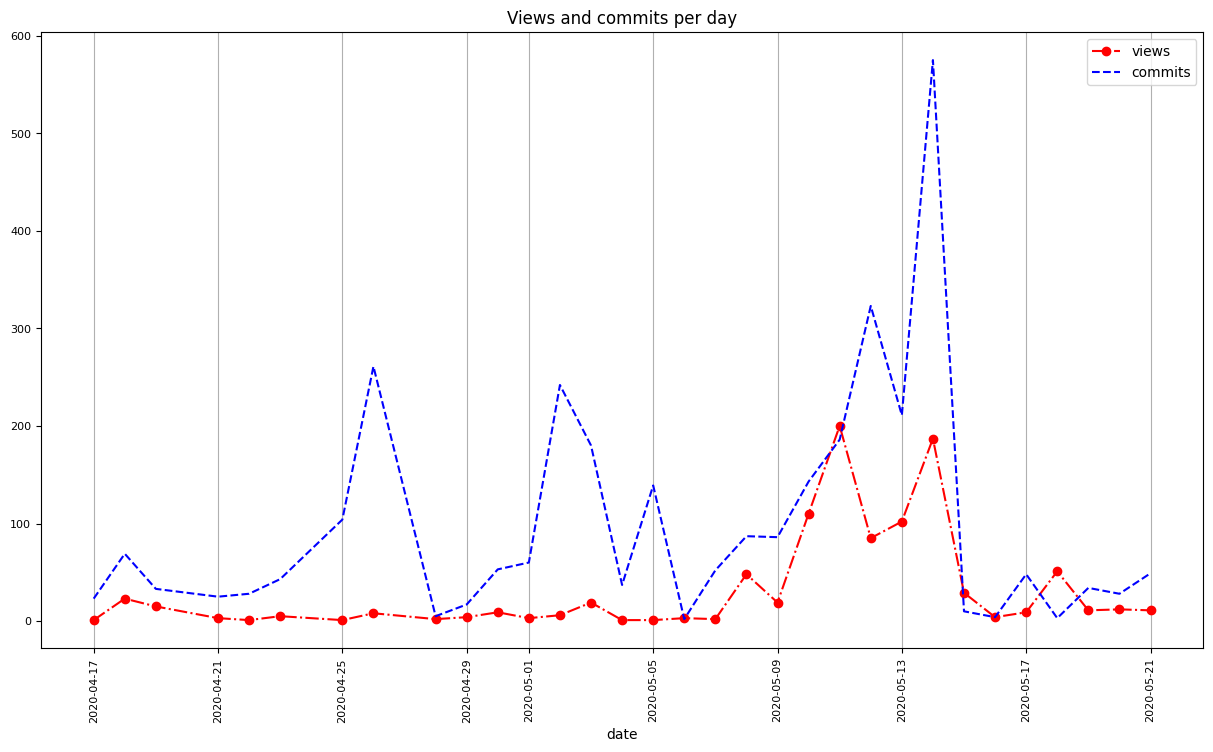

In [23]:
ax = merged.plot(
    x = 'date',
    y = ['views', 'commits'],
    title = 'Views and commits per day',
    figsize=(15,8),
    fontsize = 8,
    color=['red', 'blue'],         # views — красное, commits — синее
    style=['-.o', '--'], 
)

ax.xaxis.grid(True)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

<h2>How many times was the number of views larger than 150?</h2>

<h2>2</h2> 

In [24]:
conn.close()